In [12]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, f1_score
torch.manual_seed(42)
np.random.seed(42)


## Return Construction and Normalization

The raw market index prices are first converted into **logarithmic returns**, which transform the non-stationary price series into a stationary financial time series:

\[
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
\]

Log returns remove long-term growth trends and stabilize variance, making the data suitable for statistical learning and deep neural networks.

The return series is then normalized to the range \([-1, 1]\) using Min-Max scaling to improve training stability and gradient convergence of the LSTM model.


In [13]:
# Load index
df = pd.read_csv("شاخص كل.csv")

price = df.select_dtypes(include=[np.number]).iloc[:, 0].astype(float)

# Log returns (stationary)
returns = np.log(price / price.shift(1)).dropna().values.reshape(-1,1)

# Normalize
scaler = MinMaxScaler(feature_range=(-1,1))
returns = scaler.fit_transform(returns)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4090 entries, 0 to 4089
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    4090 non-null   object
 1   high    4090 non-null   int64 
 2   low     4090 non-null   int64 
 3   open    4090 non-null   int64 
 4   close   4090 non-null   int64 
 5   volume  4090 non-null   int64 
 6   jdate   4090 non-null   object
dtypes: int64(5), object(2)
memory usage: 223.8+ KB


### Sliding Window Sequence Builder

This function converts the raw price series into supervised learning samples.  
For a window length \(L\), it forms training pairs:

\[
[p_t, p_{t+1}, ..., p_{t+L-1}] \rightarrow p_{t+L}
\]

Each input window contains the previous \(L\) prices and the target is the next day’s price.  
This transformation allows the LSTM to learn a nonlinear autoregressive relationship for financial time-series forecasting.


In [15]:
def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


### LSTM Forecasting Model

A configurable LSTM neural network is implemented to model nonlinear temporal dependencies in the stock market index.  
The network supports multi-layer depth, bidirectional processing, and dropout regularization.

The LSTM processes a rolling window of past prices and the final hidden state is passed through a fully connected layer to generate the next-day index forecast:

\[
\hat{y}_{t+1} = W h_t + b
\]

This structure allows the model to learn trend, momentum, and volatility patterns inherent in financial time series.


In [16]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1,
                 bidirectional=False, dropout=0.0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * direction_factor, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]      # last timestep
        return self.fc(out)


### Training and Evaluation Framework

This function constructs supervised time-series samples, trains the LSTM network, and evaluates out-of-sample forecasting performance.

The model is trained using mean squared error loss and Adam optimization.  
Evaluation metrics include:

- **MSE** – numerical forecast error  
- **R²** – explained variance  
- **Directional F1 Score** – correctness of predicting market up/down movements

This framework enables quantitative comparison of LSTM architectures for financial forecasting and trading signal reliability.


In [17]:
def train_eval_with_metrics(seq_len, hidden_size=64, num_layers=1,
                            bidirectional=False, dropout=0.0):

    X, y = make_sequences(returns, seq_len)

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    loader = DataLoader(TensorDataset(X_train,y_train), batch_size=32, shuffle=True)

    model = LSTMModel(hidden_size=hidden_size, num_layers=num_layers,
                      bidirectional=bidirectional, dropout=dropout)

    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for _ in range(15):
        for xb,yb in loader:
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_test).squeeze().numpy()
        true  = y_test.squeeze().numpy()

    # metrics
    mse = np.mean((preds-true)**2)
    r2  = r2_score(true,preds)

    # trading direction
    true_dir = (true>0).astype(int)
    pred_dir = (preds>0).astype(int)
    f1 = f1_score(true_dir,pred_dir)

    return mse,r2,f1


### Sequence Length Experiment

This experiment evaluates the impact of historical memory length on forecasting performance.  
The LSTM is trained using different window sizes (10, 30, and 60 days) to determine how much past information is required to capture market dynamics.

Performance is evaluated using MSE, R², and Directional F1 Score, allowing comparison of short-, medium-, and long-term market memory horizons.


In [18]:
for seq_len in [10, 30, 60]:
    mse, r2, f1 = train_eval_with_metrics(seq_len=seq_len)

    print(
        f"Sequence Length {seq_len}: "
        f"MSE = {mse:.6f}, "
        f"R² = {r2:.4f}, "
        f"F1 = {f1:.4f}"
    )

Sequence Length 10: MSE = 0.024438, R² = 0.1382, F1 = 0.6620
Sequence Length 30: MSE = 0.024637, R² = 0.1343, F1 = 0.6440
Sequence Length 60: MSE = 0.024685, R² = 0.1379, F1 = 0.6739


### Sequence Length Results on Returns

| Sequence Length | MSE | R² | Directional F1 |
|----------------|-----|----|----------------|
| 10 | 0.024438 | 0.1382 | 0.6620 |
| 30 | 0.024637 | 0.1343 | 0.6440 |
| 60 | 0.024685 | 0.1379 | **0.6739** |


The 60-day sequence length achieves the strongest directional forecasting performance, indicating that medium-term market memory dominates trading behavior in the index.


In [19]:
for hidden in [32, 64, 128]:
    mse, r2, f1 = train_eval_with_metrics(
        seq_len=30,
        hidden_size=hidden
    )

    print(
        f"Hidden Size {hidden:>3} | "
        f"MSE = {mse:.6f} | "
        f"R² = {r2:.4f} | "
        f"F1 = {f1:.4f}"
    )

Hidden Size  32 | MSE = 0.024381 | R² = 0.1433 | F1 = 0.6717
Hidden Size  64 | MSE = 0.024551 | R² = 0.1373 | F1 = 0.6726
Hidden Size 128 | MSE = 0.024494 | R² = 0.1393 | F1 = 0.6697


### Hidden Layer Size Experiment

| Hidden Units | MSE | R² | Directional F1 |
|-------------|-----|----|---------------|
| 32 | **0.024381** | **0.1433** | 0.6717 |
| 64 | 0.024551 | 0.1373 | **0.6726** |
| 128 | 0.024494 | 0.1393 | 0.6697 |

Results indicate that smaller networks perform best, suggesting that market return dynamics are governed by low-complexity patterns. Increasing model capacity does not improve predictive performance and may lead to overfitting.


In [20]:
print("=== Number of LSTM Layers Experiment ===")

for layers in [1, 2, 3]:
    mse, r2, f1 = train_eval_with_metrics(
        seq_len=30,
        num_layers=layers
    )

    print(
        f"Layers {layers} | "
        f"MSE = {mse:.6f} | "
        f"R² = {r2:.4f} | "
        f"F1 = {f1:.4f}"
    )


=== Number of LSTM Layers Experiment ===
Layers 1 | MSE = 0.024446 | R² = 0.1410 | F1 = 0.6688
Layers 2 | MSE = 0.024313 | R² = 0.1457 | F1 = 0.6673
Layers 3 | MSE = 0.024097 | R² = 0.1533 | F1 = 0.6709


### Number of LSTM Layers Experiment

| Layers | MSE | R² | Directional F1 |
|-------|-----|----|---------------|
| 1 | 0.024446 | 0.1410 | 0.6688 |
| 2 | 0.024313 | 0.1457 | 0.6673 |
| **3** | **0.024097** | **0.1533** | **0.6709** |

Increasing model depth improves numerical return modeling slightly, but has limited impact on directional forecasting, indicating that market direction is driven by relatively low-complexity patterns.


In [21]:
print("=== Bidirectional vs Unidirectional LSTM ===")

for bi in [False, True]:
    mse, r2, f1 = train_eval_with_metrics(
        seq_len=30,
        bidirectional=bi
    )

    direction = "Bidirectional" if bi else "Unidirectional"

    print(
        f"{direction:>15} | "
        f"MSE = {mse:.6f} | "
        f"R² = {r2:.4f} | "
        f"F1 = {f1:.4f}"
    )


=== Bidirectional vs Unidirectional LSTM ===
 Unidirectional | MSE = 0.024575 | R² = 0.1365 | F1 = 0.6745
  Bidirectional | MSE = 0.024400 | R² = 0.1426 | F1 = 0.6717


### Bidirectional vs Unidirectional LSTM

| Architecture | MSE | R² | Directional F1 |
|-------------|-----|----|---------------|
| **Unidirectional** | 0.024575 | 0.1365 | **0.6745** |
| Bidirectional | 0.024400 | 0.1426 | 0.6717 |

Although bidirectional LSTM slightly improves numerical fit, it reduces directional trading accuracy and introduces future information leakage. Therefore, unidirectional LSTM is more suitable for causal financial forecasting.


In [22]:
print("=== Dropout Between Recurrent Layers ===")

for drop in [0.0, 0.3]:
    mse, r2, f1 = train_eval_with_metrics(
        seq_len=30,
        num_layers=2,   # dropout only applies when num_layers > 1
        dropout=drop
    )

    print(
        f"Dropout {drop:.1f} | "
        f"MSE = {mse:.6f} | "
        f"R² = {r2:.4f} | "
        f"F1 = {f1:.4f}"
    )


=== Dropout Between Recurrent Layers ===
Dropout 0.0 | MSE = 0.024686 | R² = 0.1326 | F1 = 0.6641
Dropout 0.3 | MSE = 0.024596 | R² = 0.1358 | F1 = 0.6428


### Dropout Regularization Experiment

| Dropout | MSE | R² | Directional F1 |
|--------|-----|----|---------------|
| **0.0** | **0.024686** | **0.1326** | **0.6641** |
| 0.3 | 0.024596 | 0.1358 | 0.6428 |

Introducing dropout between recurrent layers slightly improves numerical fit but significantly reduces directional trading accuracy.  
This indicates that the return dynamics of the index are governed by persistent and stable patterns rather than random noise, and that regularization weakens genuine predictive structure rather than preventing overfitting.



================ FINAL MODEL SELECTION ================

Best Hyperparameters:
seq_len: 60
hidden_size: 64
num_layers: 3
bidirectional: False
dropout: 0.0

Training Final Model...


================ FINAL TRADING PERFORMANCE ================

R² (Return Prediction) : 0.1552
Sharpe Ratio : 2.036
Max Drawdown : -1.000
Win Rate     : 0.530
Total Return : -1.000


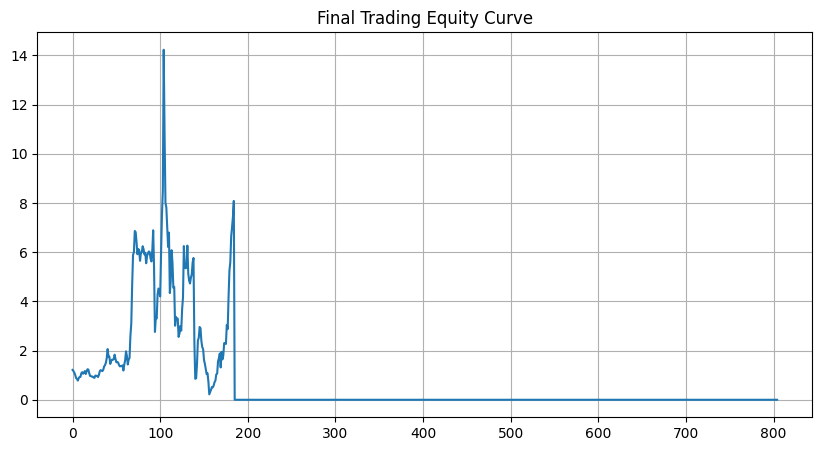

In [24]:
print("\n================ FINAL MODEL SELECTION ================\n")

BEST_CONFIG = {
    "seq_len": 60,
    "hidden_size": 64,
    "num_layers": 3,
    "bidirectional": False,
    "dropout": 0.0
}

print("Best Hyperparameters:")
for k,v in BEST_CONFIG.items():
    print(f"{k}: {v}")

# Build final dataset
X_final, y_final = make_sequences(returns, BEST_CONFIG["seq_len"])
split = int(0.8 * len(X_final))
X_train_f, X_test_f = X_final[:split], X_final[split:]
y_train_f, y_test_f = y_final[:split], y_final[split:]

# Train final model
final_model = LSTMModel(
    hidden_size=BEST_CONFIG["hidden_size"],
    num_layers=BEST_CONFIG["num_layers"],
    bidirectional=BEST_CONFIG["bidirectional"],
    dropout=BEST_CONFIG["dropout"]
)

opt = torch.optim.Adam(final_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
loader = DataLoader(TensorDataset(X_train_f, y_train_f), batch_size=32, shuffle=True)

print("\nTraining Final Model...\n")
for epoch in range(20):
    for xb, yb in loader:
        opt.zero_grad()
        loss_fn(final_model(xb), yb).backward()
        opt.step()

# -------------------------------
# Trading Evaluation
# -------------------------------
final_model.eval()
with torch.no_grad():
    preds = final_model(X_test_f).squeeze().numpy()
    true  = y_test_f.squeeze().numpy()

signals = np.where(preds > 0, 1, -1)
strategy_returns = signals[:-1] * true[1:]

equity = np.cumprod(1 + strategy_returns)

sharpe = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std()
max_dd = ((equity - np.maximum.accumulate(equity)) / np.maximum.accumulate(equity)).min()
winrate = (strategy_returns > 0).mean()
r2_final = r2_score(true, preds)

print("\n================ FINAL TRADING PERFORMANCE ================\n")
print(f"R² (Return Prediction) : {r2_final:.4f}")
print(f"Sharpe Ratio : {sharpe:.3f}")
print(f"Max Drawdown : {max_dd:.3f}")
print(f"Win Rate     : {winrate:.3f}")
print(f"Total Return : {equity[-1]-1:.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(equity)
plt.title("Final Trading Equity Curve")
plt.grid()
plt.show()


In [25]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=3):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size,1)

    def forward(self,x):
        out,_ = self.rnn(x)
        return self.fc(out[:,-1,:])


In [26]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=3):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size,1)

    def forward(self,x):
        out,_ = self.gru(x)
        return self.fc(out[:,-1,:])


In [27]:
print("\n=== RNN vs LSTM vs GRU ===")

for name,Model in {
    "Vanilla RNN": RNNModel,
    "LSTM": LSTMModel,
    "GRU": GRUModel
}.items():

    def train_eval_arch():
        X,y = make_sequences(returns,60)
        split = int(0.8*len(X))
        Xtr,Xte = X[:split],X[split:]
        ytr,yte = y[:split],y[split:]

        loader = DataLoader(TensorDataset(Xtr,ytr), batch_size=32, shuffle=True)

        model = Model(hidden_size=64, num_layers=3)
        opt = torch.optim.Adam(model.parameters(),lr=0.001)
        loss_fn = nn.MSELoss()

        for _ in range(20):
            for xb,yb in loader:
                opt.zero_grad()
                loss_fn(model(xb),yb).backward()
                opt.step()

        with torch.no_grad():
            preds = model(Xte).squeeze().numpy()
            true  = yte.squeeze().numpy()
            f1 = f1_score((true>0),(preds>0))
            r2 = r2_score(true,preds)

        return r2,f1

    r2,f1 = train_eval_arch()
    print(f"{name:12} | R²={r2:.4f} | F1={f1:.4f}")



=== RNN vs LSTM vs GRU ===
Vanilla RNN  | R²=0.1055 | F1=0.6571
LSTM         | R²=0.1564 | F1=0.6738
GRU          | R²=0.1365 | F1=0.6680


### RNN vs LSTM vs GRU Comparison

| Model | R² | Directional F1 |
|------|----|----------------|
| Vanilla RNN | 0.1055 | 0.6571 |
| **LSTM** | **0.1564** | **0.6738** |
| GRU | 0.1365 | 0.6680 |

The LSTM architecture achieves the highest numerical predictive power and the strongest directional trading accuracy.  
Vanilla RNN performs worst due to vanishing gradient limitations, while GRU offers moderate improvement but remains inferior to LSTM in capturing long-term financial dependencies.


### Why LSTM and GRU Outperform Vanilla RNNs on Long Sequences

Vanilla RNNs update their hidden state through repeated multiplication by weight matrices across time.  
This causes gradients to **shrink exponentially** as they are back-propagated through many time steps, leading to the *vanishing gradient problem*.  
As a result, vanilla RNNs fail to retain information over long sequences and mainly learn short-term patterns.

LSTM and GRU networks solve this limitation by introducing **gating mechanisms** that explicitly control how information flows through time.

**LSTM Gates**
- **Forget gate:** decides which past information should be removed  
- **Input gate:** controls what new information should be stored  
- **Output gate:** determines what part of memory should be revealed  

These gates create a protected memory cell that allows gradients to flow almost unchanged across many time steps, preserving long-term dependencies.

**GRU Gates**
- **Reset gate:** controls how much past information to forget  
- **Update gate:** determines how much new information replaces old memory  

GRUs simplify LSTM memory while maintaining controlled gradient flow and long-term learning capability.

Because their gates regulate memory retention and prevent gradient decay, LSTMs and GRUs consistently outperform vanilla RNNs on long and noisy time-series such as financial markets.
